In [2]:
import numpy as np
import glob
import os
from datetime import datetime
from datetime import timedelta
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cft

import time
import numpy as np
from netCDF4 import Dataset
import thermofeel as thermofeel #for MRT
from wrf import getvar #for RH
import pythermalcomfort
from pythermalcomfort.models import utci #for UTCI
import pickle

from datetime import datetime
import matplotlib.pyplot as plt

ERROR 1: PROJ: proj_create_from_database: Open of /g/data/xp65/public/./apps/med_conda/envs/analysis3-25.09/share/proj failed
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.09/lib/python3.11/site-packages/wrf/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


Plot the temporal evolution of spatial maps of 2m temperature, wind speed, MRT, albedo, and absolute humidity - Figures 6, 8-9, S13, S15

In [ ]:
#code to extract variables of interest from Default, LCZ, WSF3DMSB, and Geoscape cases

# Constants
Rd = 287.05  # J/kg/K

# file paths
paths = {
    "Default(Bulk+NoUCM)": "/g/data/fy29/mf9078/run_WRF/etamodified/output/0out/animation/",
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

# Define diurnal periods
periods = {
    'bsr': {'hours': list(range(2, 6)), 'first_hour': 2},      # 2-5 am: before sunrise
    'morning': {'hours': list(range(7, 11)), 'first_hour': 7}, # 7-10 am: morning
    'peak': {'hours': list(range(11, 15)), 'first_hour': 11},  # 11 am-2 pm: peak solar heating
    'aft': {'hours': list(range(15, 19)), 'first_hour': 15},   # 3-6 pm: late afternoon
    'eve': {'hours': list(range(19, 23)), 'first_hour': 19}    # 7-10 pm: evening
}

# Dictionary to store results for each scenario, period, and variable
results = {}

# Loop through all the scenarios
for label, sc_path in paths.items():
    file_list = sorted(glob.glob(os.path.join(sc_path, "wrfout_d02_2017-01-*")))
    
    # Initialize results structure for this scenario
    results[label] = {}
    
    # Initialize for each period
    for period_name in periods.keys():
        results[label][period_name] = {'var_sums': {}, 'n': 0}
    
    # Loop through files
    for fpath in file_list:
        ds = xr.open_dataset(fpath)
        # Load WRF NetCDF file for getting RH using wrf-python (getvar)
        ncfile = Dataset(fpath)
        
        # Parse timestamp and convert to AEST
        timestamp_utc = datetime.strptime(os.path.basename(fpath)[11:], "%Y-%m-%d_%H:%M:%S")
        timestamp_aest = timestamp_utc + timedelta(hours=10)
        
        # Extract all variables (only if we're in one of our time periods)
        current_hour = timestamp_aest.hour
        for period_name, period_info in periods.items():
            if current_hour in period_info['hours']:
                if label == "Default(Bulk+NoUCM)":
                    MRT=thermofeel.calculate_mean_radiant_temperature(
                        ssrd=ds['SWDNB'].values,   # Surface short-wave (solar) radiation downwards
                        ssr=ds['GSW'].values,      # Surface net short-wave (solar) radiation
                        dsrp=ds['SWDDNI'].values,  # Surface direct normal short-wave (solar) radiation
                        strd=ds['LWDNB'].values,   # Surface long-wave (thermal) radiation downwards
                        fdir=ds['SWDDIR'].values,  # Surface direct short-wave (solar) radiation
                        strr=(ds['LWDNB']-ds['LWUPB']).values,          # Surface net thermal radiation
                        cossza=ds['COSZEN'].values # cosine of solar zenith angle
                    )
                    # Convert back to xarray DataArray using coordinates from original dataset
                    # Use one of your input variables as a template for coordinates/dimensions
                    MRT_xr = xr.DataArray(
                        MRT,
                        coords=ds['SWDNB'].coords,  # Use coords from one of the input variables
                        dims=ds['SWDNB'].dims,      # Use dims from one of the input variables
                        name='MRT',
                        attrs={'units': 'K', 'long_name': 'Mean Radiant Temperature'}  # Optional metadata
                    )
                    ds['MRT'] = MRT_xr
                    variables = {
                        'AL': ds["ALBEDO"],
                        'T': ds["T2"], 
                        'U10': ds["U10"],
                        'V10': ds["V10"],
                        'HFX': ds['HFX'],
                        'LH': ds['LH'],
                        'MU': ds["MU"],
                        'Q2': ds["Q2"],
                        'PSFC': ds["PSFC"],
                        'TSK': ds["TSK"],
                        've': ds["FVEG"],
                        'el': ds["HGT"],
                        'MRT': ds['MRT']
                    }
                else:
                    # Extract TMR variables
                    tmr_11 = ds["TMR_11"]
                    tmr_12 = ds["TMR_12"]
                    tmr_13 = ds["TMR_13"]
                    tmr_21 = ds["TMR_21"]
                    tmr_22 = ds["TMR_22"]
                    tmr_23 = ds["TMR_23"]
                
                    # Stack all TMR variables along a new dimension for easier max/min calculation
                    # Create a 4D array: [time, south_north, west_east, tmr_components]
                    tmr_stack = xr.concat([tmr_11, tmr_12, tmr_13, tmr_21, tmr_22, tmr_23], 
                                        dim='tmr_component')
                
                    # Calculate TMR_max and TMR_min (ignoring NaN values)
                    tmr_max = tmr_stack.max(dim='tmr_component', skipna=True)
                
                    # Where all TMR values are NaN, the result should also be NaN
                    # Check if all TMR values are NaN for each grid point
                    all_nan_mask = tmr_stack.isnull().all(dim='tmr_component')
                    tmr_max = tmr_max.where(~all_nan_mask)
                
                    variables = {
                        'AL': ds["ALBEDO"],
                        'T': ds["T2"], 
                        'U10': ds["U10"],
                        'V10': ds["V10"],
                        'HFX': ds['HFX'],
                        'LH': ds['LH'],
                        'MU': ds["MU"],
                        'Q2': ds["Q2"],
                        'PSFC': ds["PSFC"],
                        'TSK': ds["TSK"],
                        've': ds["FVEG"],
                        'el': ds["HGT"],
                        'MRT': tmr_max
                    }
                
                # Calculate derived variables
                variables['WS'] = np.sqrt(variables['U10']**2 + variables['V10']**2)
                tv = variables['T'] * (1 + 0.61 * variables['Q2'])
                rho_air = variables['PSFC'] / (Rd * tv)
                variables['AH'] = rho_air * variables['Q2']  # kg/m³ absolute humidity
                
                # First entry for this period or accumulate
                is_first_entry = (timestamp_aest.day == 10 and current_hour == period_info['first_hour'])
                
                if is_first_entry:
                    results[label][period_name]['var_sums'] = {key: val for key, val in variables.items()}
                    results[label][period_name]['n'] = 1
                else:
                    # Only accumulate if we already have data for this period
                    if results[label][period_name]['var_sums']:
                        for key, val in variables.items():
                            results[label][period_name]['var_sums'][key] += val
                        results[label][period_name]['n'] += 1
                
                break  # Don't check other periods once we found a match

# Calculate averages and restructure results
final_results = {}
for label in paths.keys():
    final_results[label] = {}
    for period_name in periods.keys():
        final_results[label][period_name] = {}
        if results[label][period_name]['var_sums']:  # Only if we have data
            n = results[label][period_name]['n']
            for var_name, var_sum in results[label][period_name]['var_sums'].items():
                final_results[label][period_name][var_name] = var_sum / n

# Replace the original results dictionary
results = final_results

with open("/g/data/gb02/mf9078/spatialanalysis.pkl", "wb") as f:
    pickle.dump(results, f) 

# Access results like this:
# results["LCZ"]["bsr"]["AL"] - LCZ albedo during before sunrise
# results["WSF3DMSB"]["morning"]["T"] - WSF3DMSB temperature during morning
# results["Geoscape"]["peak"]["WS"] - Geoscape wind speed during peak hours

In [6]:
with open("/g/data/gb02/mf9078/spatialanalysis.pkl", "rb") as f:
    results = pickle.load(f) 

In [7]:
# mask
lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00" #any wrfout with 10-category LCZ, i.e., any scenario but bulk

# Initialize on first file to get the subset bounds and mask
ds = xr.open_dataset(file_luindex) 
XLAT = ds["XLAT"]
XLONG = ds["XLONG"]
LU_INDEX = ds["LU_INDEX"]

lat_mask = (XLAT >= lat_min) & (XLAT <= lat_max)
lon_mask = (XLONG >= lon_min) & (XLONG <= lon_max)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask

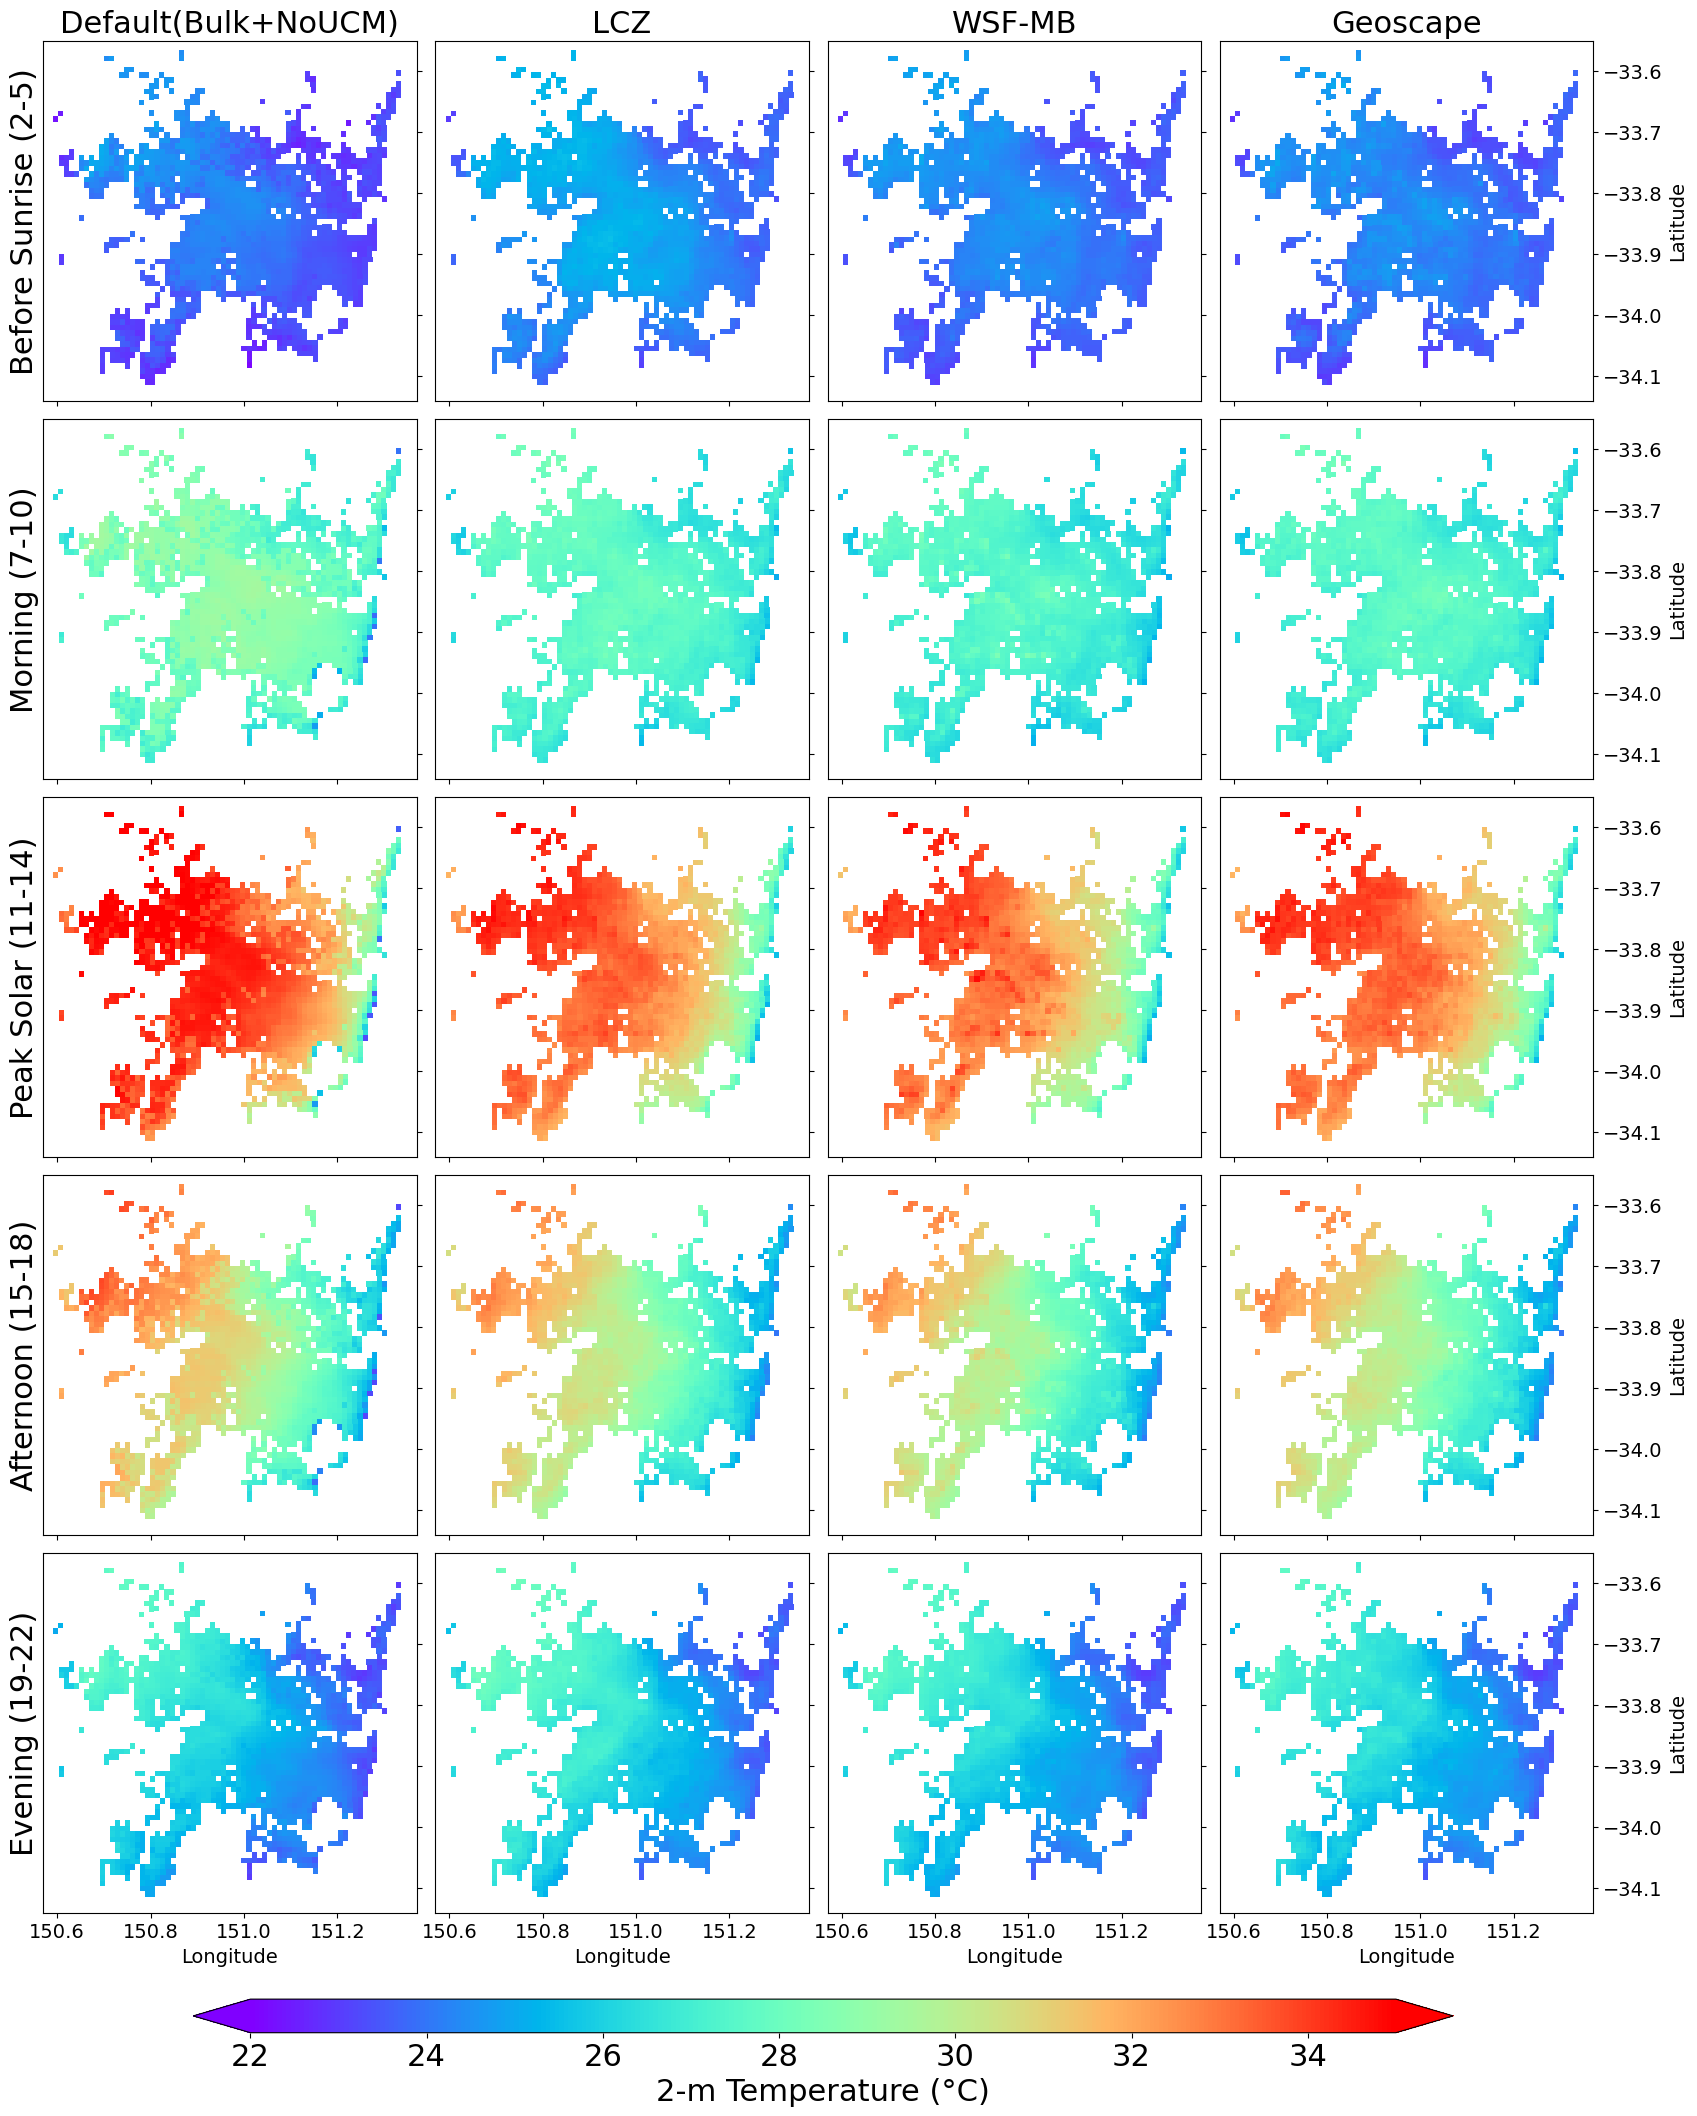

In [ ]:
#2m temperature
# Define scenarios and periods
scenarios = ["Default(Bulk+NoUCM)","LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

# AWS locations
urbanaws = ['SA','OH','BA','CR','OP']
awslat = [-33.9465,-33.8607,-33.9176,-33.9057,-33.8338]
awslon = [151.1731,151.205,150.9837,151.1134,151.0718]

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x4 subplots
fig, axs = plt.subplots(5, 4, figsize=(20, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["T"].where(region_mask) - 273.15
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='rainbow',
            vmin=22,
            vmax=35,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
        
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=22)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        if col == 0:  # Left column - add period labels
            ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
                   fontsize=22, rotation=90, #fontweight='bold', 
                   verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=14)
        else:
            ax.set_xlabel("")
            
        if col == 3:  # Left column
            ax.set_ylabel("Latitude", fontsize=14)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 3:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=22)
cbar.set_label("2-m Temperature (°C)", fontsize=22)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("T-5x4-all_periods-points.png", 
           bbox_inches='tight', dpi=300)
plt.show()

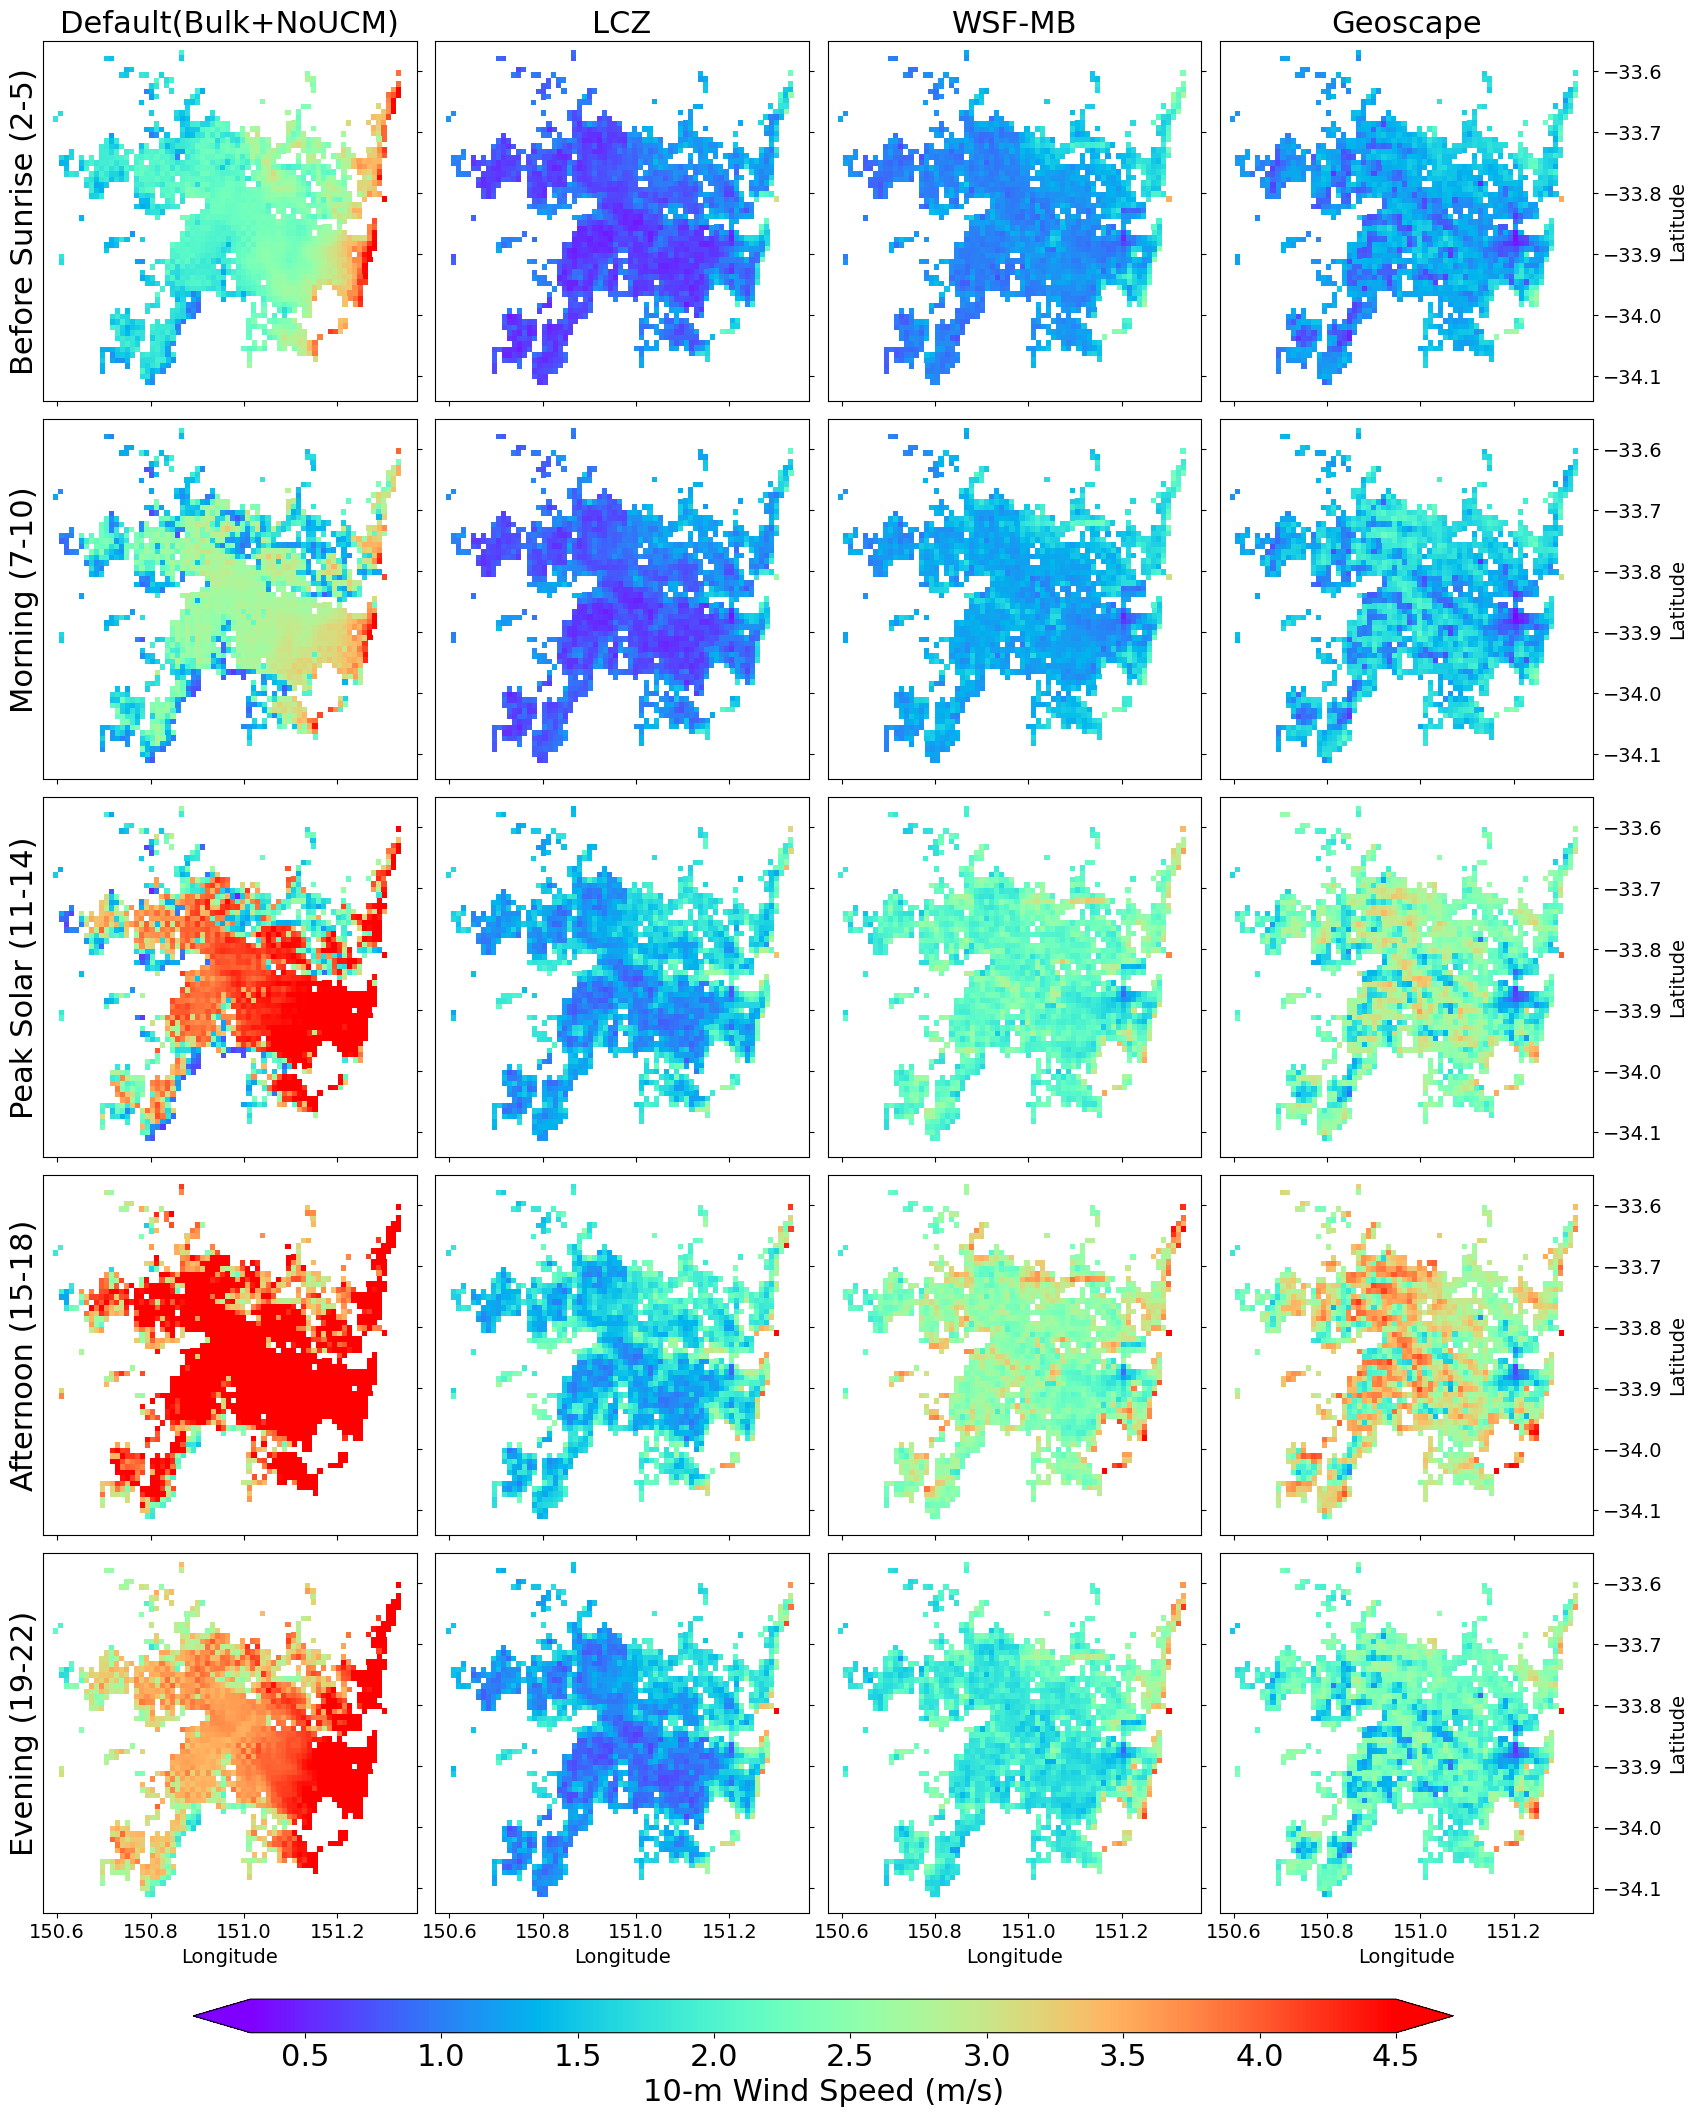

In [ ]:
#Wind speed

# Define scenarios and periods
scenarios = ["Default(Bulk+NoUCM)","LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 4, figsize=(20, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["WS"].where(region_mask) 
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='rainbow',
            vmin=0.3,
            vmax=4.5,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
        
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=22)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        if col == 0:  # Left column - add period labels
            ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
                   fontsize=22, rotation=90, #fontweight='bold', 
                   verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=14)
        else:
            ax.set_xlabel("")
            
        if col == 3:  # Left column
            ax.set_ylabel("Latitude", fontsize=14)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 3:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=22)
cbar.set_label("10-m Wind Speed (m/s)", fontsize=22)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("WS-5x4-all_periods.png", 
           bbox_inches='tight', dpi=300)
plt.show()

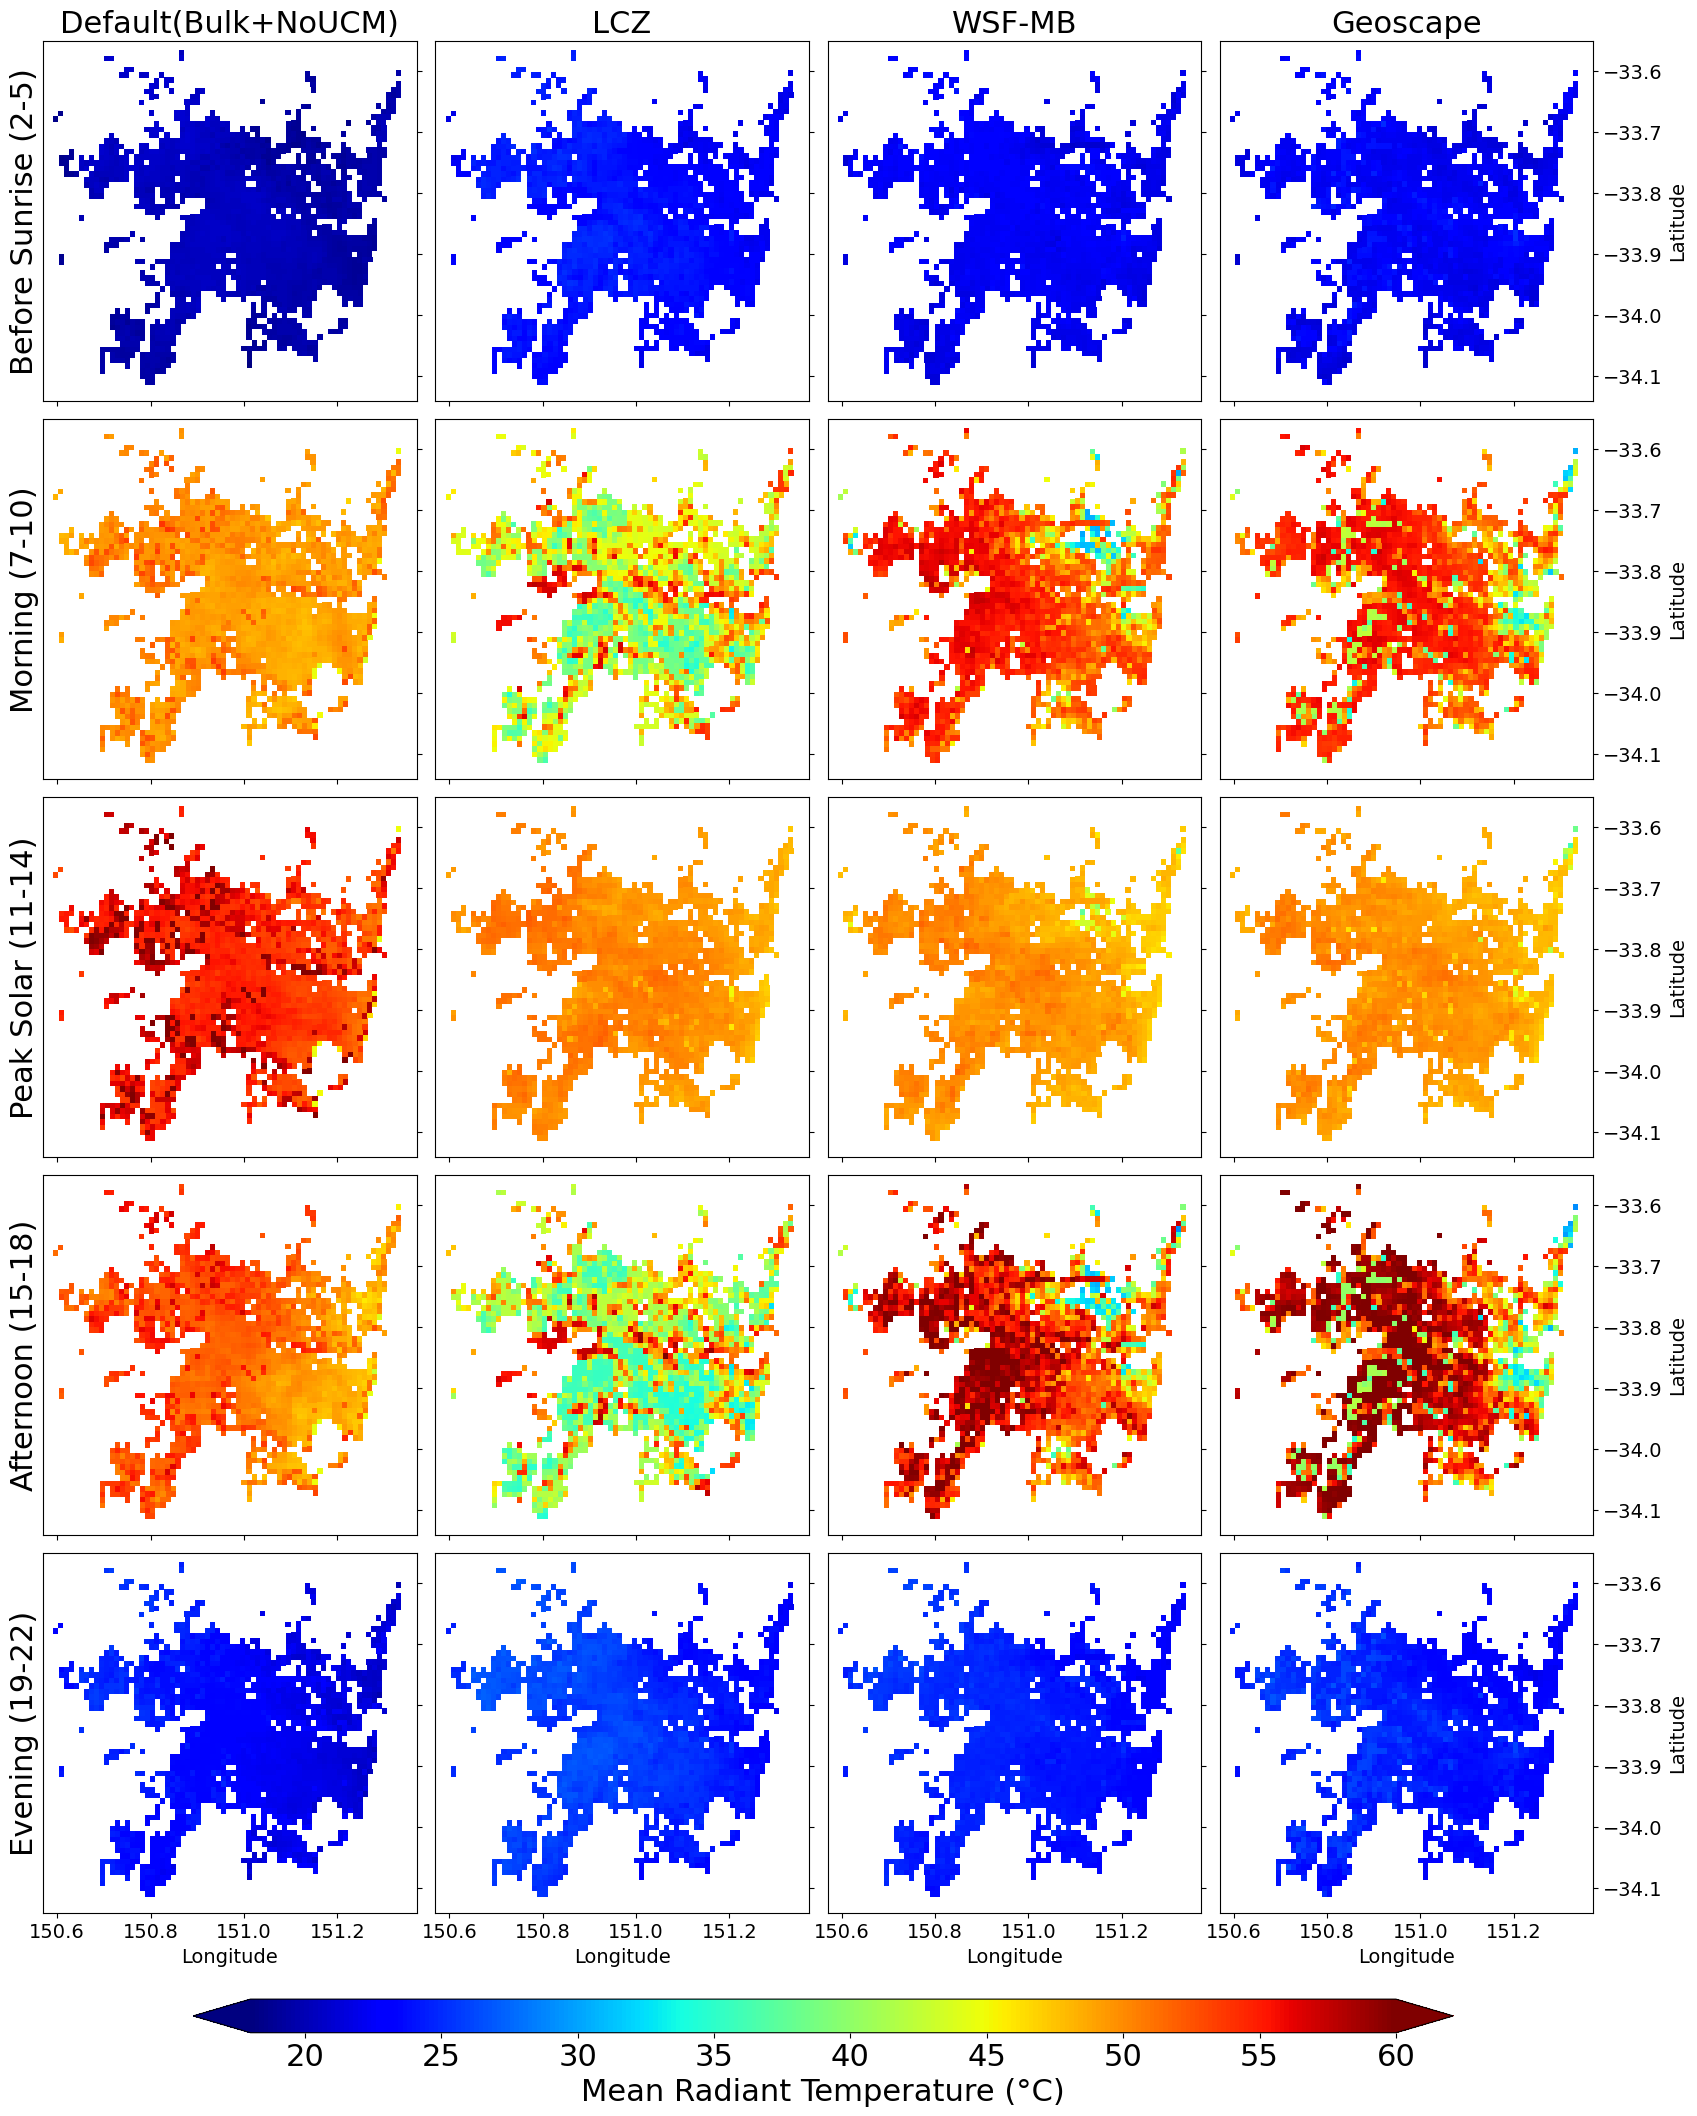

In [ ]:
#max of MRT (for Default calculated from thermofeel)

# Define scenarios and periods
scenarios = ["Default(Bulk+NoUCM)","LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 4, figsize=(20, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["MRT"].where(region_mask) -273.15
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='jet',
            vmin=18,#15,#22,
            vmax=60,#62, #35,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
        
        
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=22)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        if col == 0:  # Left column - add period labels
            ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
                   fontsize=22, rotation=90, #fontweight='bold', 
                   verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=14)
        else:
            ax.set_xlabel("")
            
        if col == 3:  # Left column
            ax.set_ylabel("Latitude", fontsize=14)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 3:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=22)
cbar.set_label("Mean Radiant Temperature (°C)", fontsize=22)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("MRT-defaultNmax-5x4-all_periods.png", 
           bbox_inches='tight', dpi=300)
plt.show()

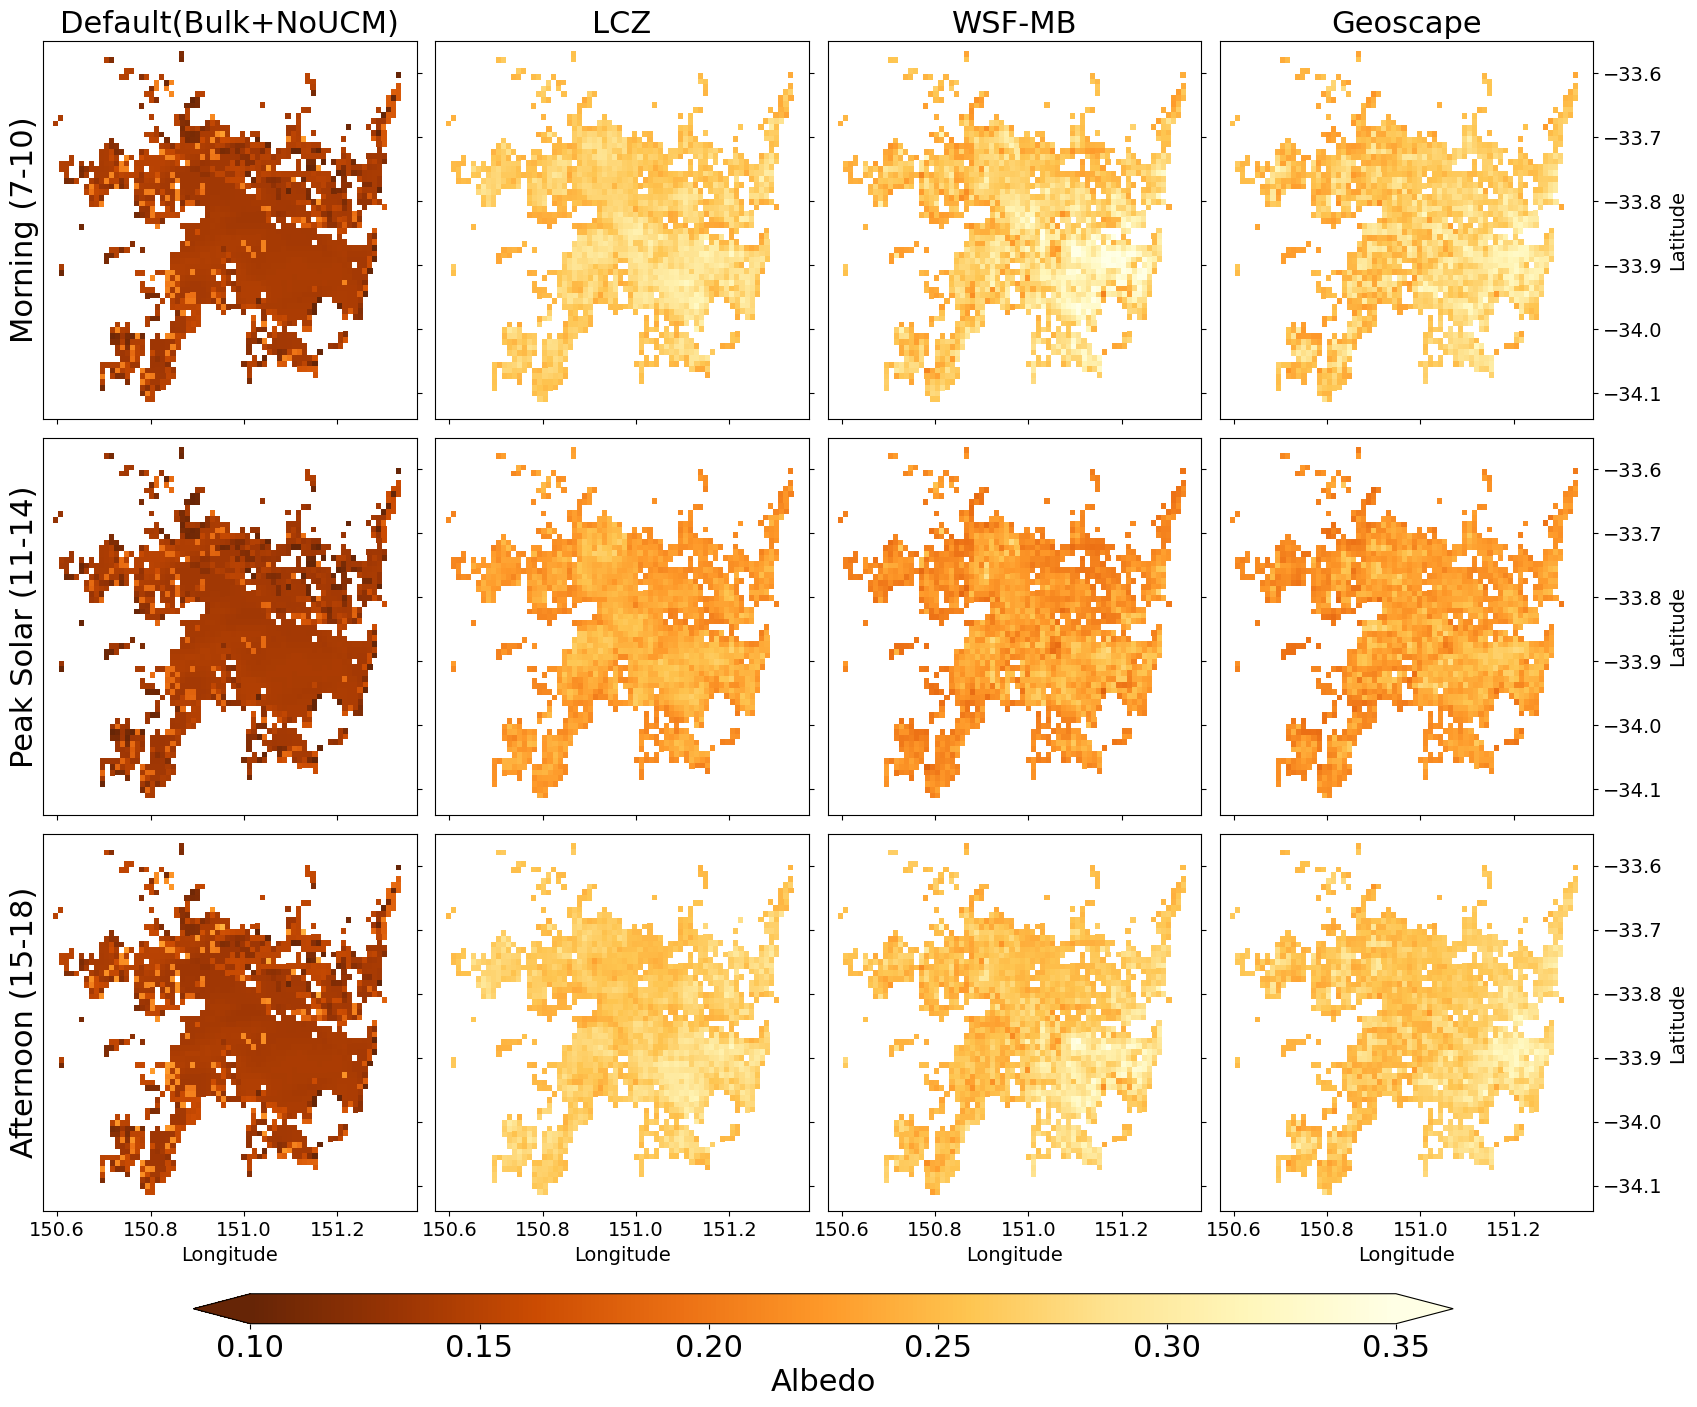

In [ ]:
#Albedo

# Define scenarios and periods
scenarios = ["Default(Bulk+NoUCM)","LCZ", "WSF-MB", "Geoscape"]
periods = ["morning", "peak", "aft"]
period_labels = {
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(3, 4, figsize=(20, 15), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["AL"].where(region_mask)
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='YlOrBr_r',
            vmin=0.1,
            vmax=0.35,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
        
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=22)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        if col == 0:  # Left column - add period labels
            ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
                   fontsize=22, rotation=90, #fontweight='bold', 
                   verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=14)
        else:
            ax.set_xlabel("")
            
        if col == 3:  # Left column
            ax.set_ylabel("Latitude", fontsize=14)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 3:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.025, 0.63, 0.02])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=22)
cbar.set_label("Albedo", fontsize=22)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("AL-5x4-all_periods.png", 
           bbox_inches='tight', dpi=300)
plt.show()

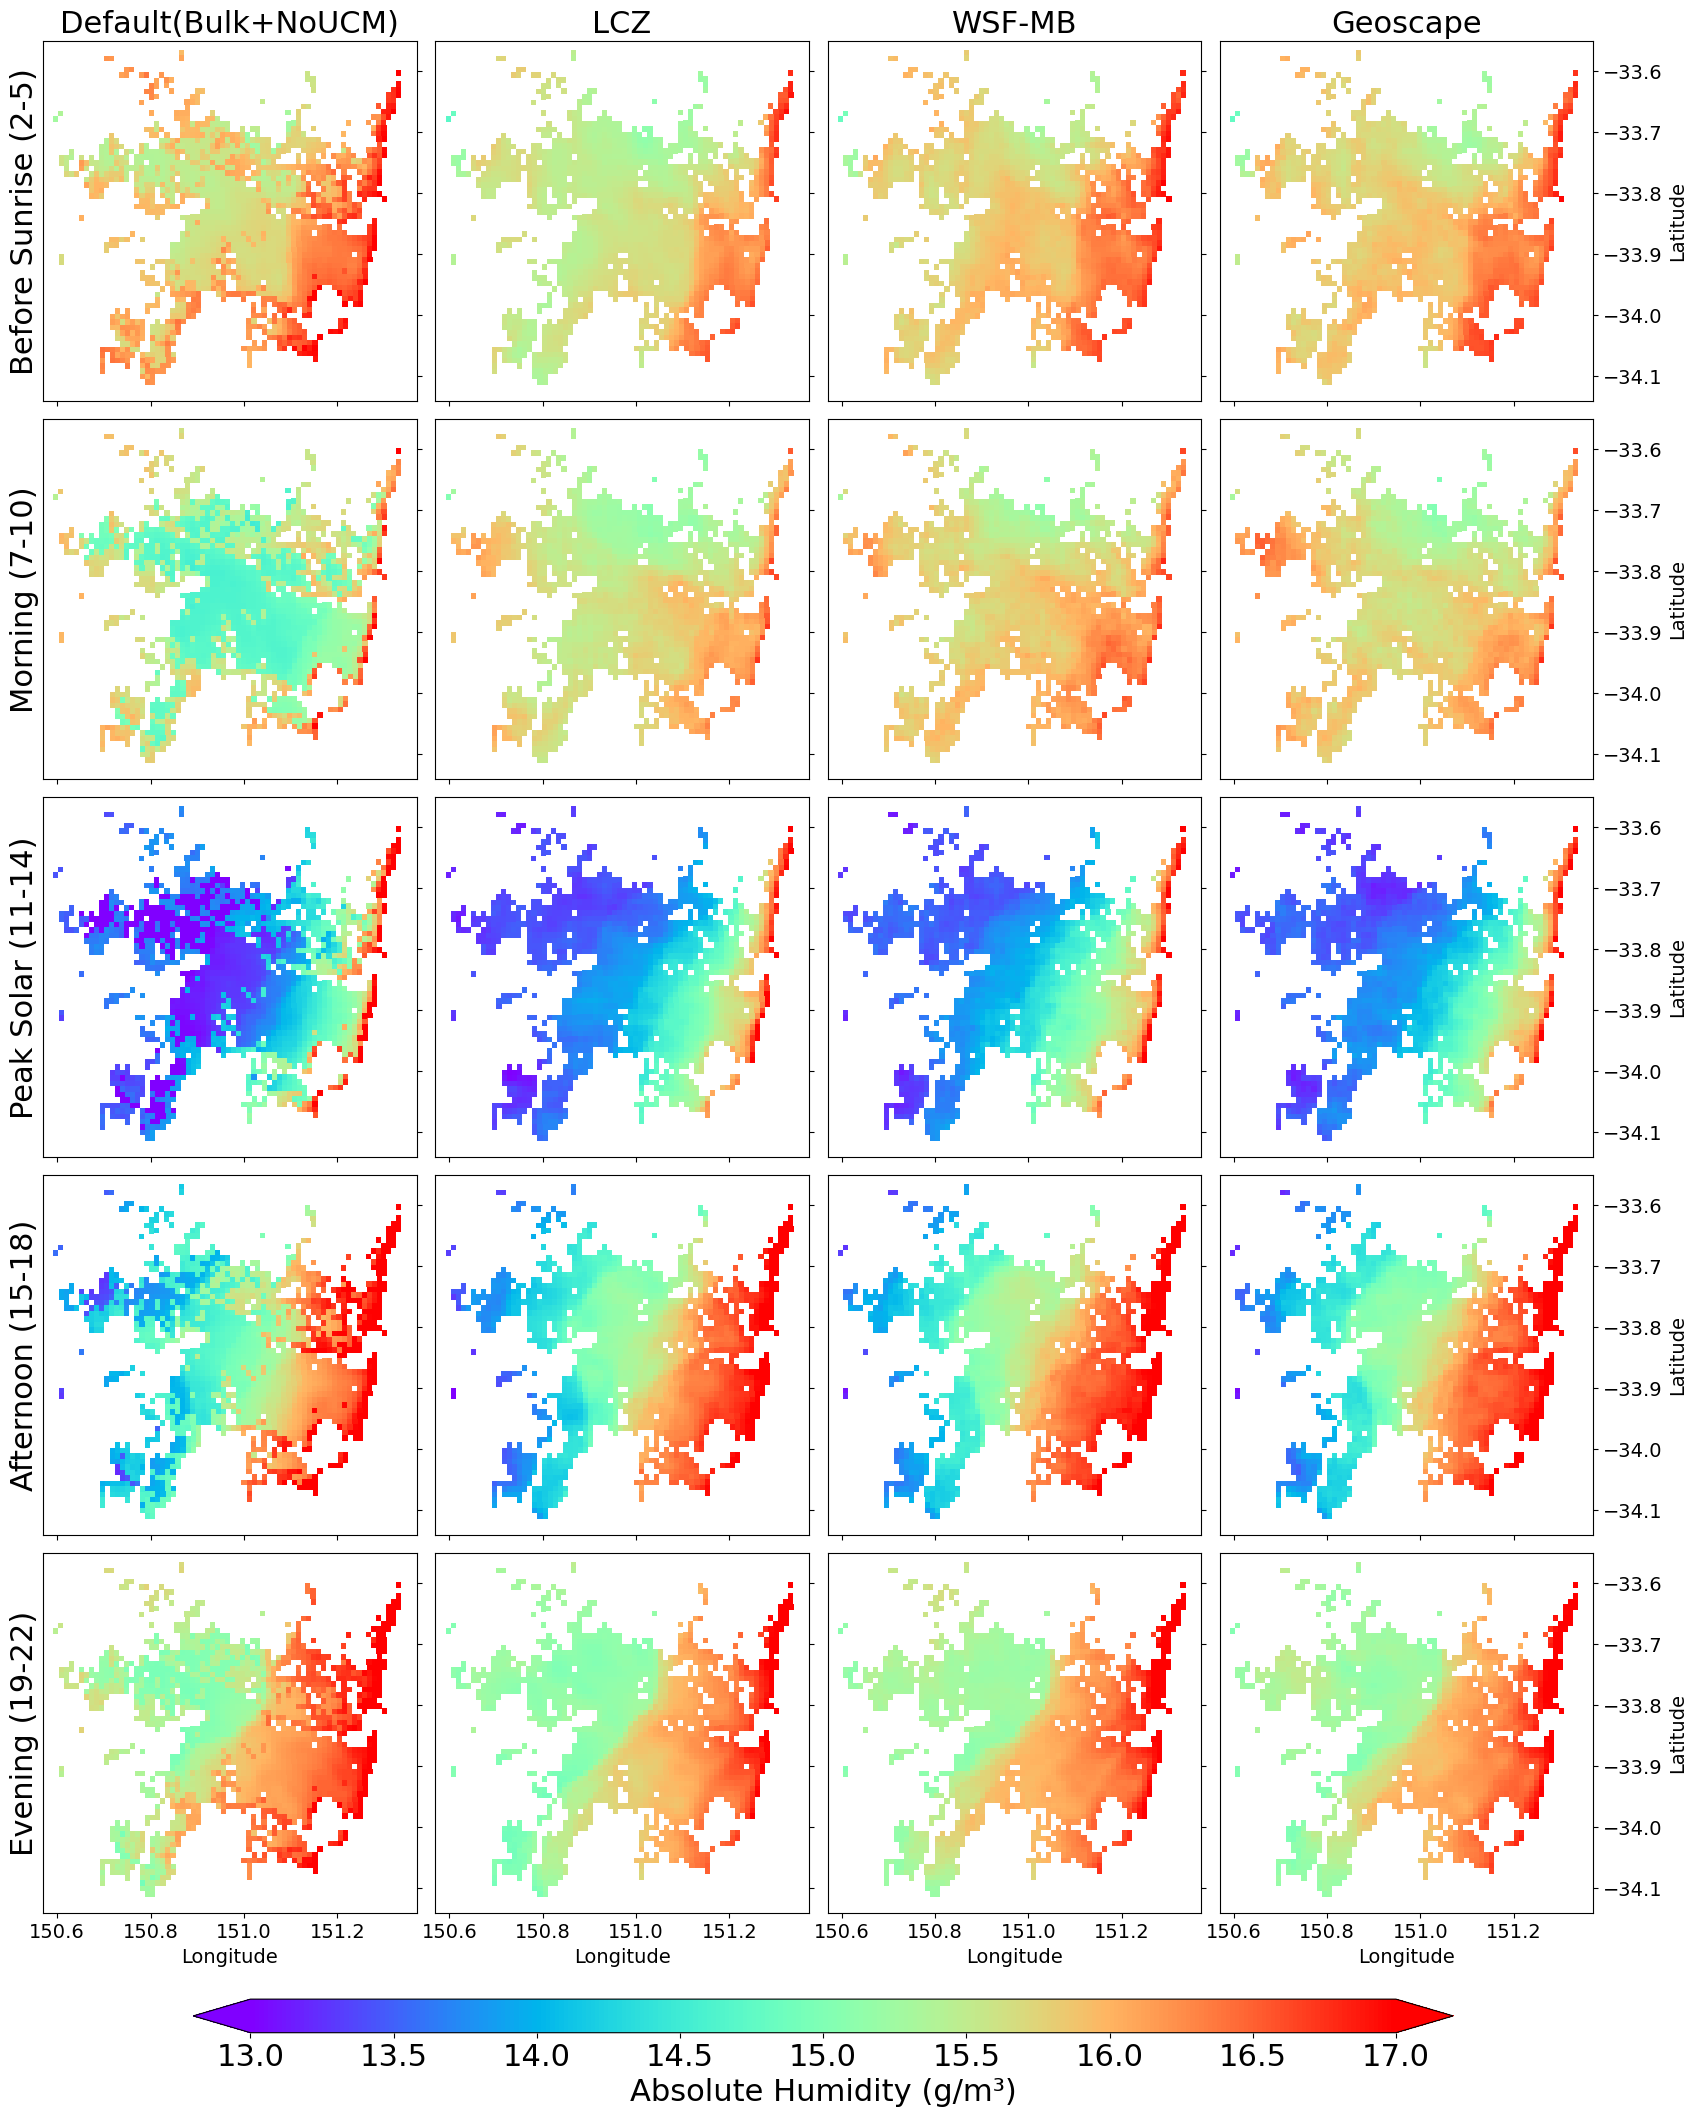

In [ ]:
#Absolute humidity

# Define scenarios and periods
scenarios = ["Default(Bulk+NoUCM)","LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 4, figsize=(20, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["AH"].where(region_mask) * 1000
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='rainbow',
            vmin=13,
            vmax=17,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
        
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=22)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        if col == 0:  # Left column - add period labels
            ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
                   fontsize=22, rotation=90, #fontweight='bold', 
                   verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=14)
        else:
            ax.set_xlabel("")
            
        if col == 3:  # Left column
            ax.set_ylabel("Latitude", fontsize=14)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 3:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=14)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=22)
cbar.set_label("Absolute Humidity (g/m³)", fontsize=22)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("AH-5x4-all_periods.png", 
           bbox_inches='tight', dpi=300)
plt.show()